# Foster–Cauer conversion and error

This notebook separates **exact terminal circuit conversion** from **approximate model construction**. A finite rational impedance can have Foster and Cauer realizations with identical terminal response. Converting that same function does not improve its approximation to a field problem.

Physical CLN construction additionally produces electric and magnetic field modes for a specified excitation. The original CLN work constructs these modes sequentially using finite elements [1]. A circuit synthesized only from terminal data does not recover those field modes. Data-driven Cauer synthesis and the Foster-to-Cauer route are discussed by Otomo and Igarashi [2].

This executable example covers scalar, finite, passive RL impedances with simple negative real poles, using low-frequency series-R/shunt-L extraction at **s0 = 0**. It is not an implementation of shifted Type1/Type2 field recurrences, arbitrary RLC synthesis, or multiport conversion. The Type1/Type2 labels used in this repository should not be identified automatically with historical Cauer I/II conventions.

See [the physical formulation notebook](02_formulations_gauge_boundary.ipynb), [shifted Type1](type1_same_circuit.ipynb), and [shifted Type2](type2_same_circuit.ipynb).

The exact conversion helpers reject floating-point coefficients. If a decimal or fitted model is to be converted, callers must explicitly choose a rational approximation (for example `sp.nsimplify(z, rational=True)`) and assess its error separately. The helper verifies exact reconstruction of the chosen rational function. Real polynomial poles are isolated exactly, including `CRootOf` representations when radicals cannot certify their signs; numerical pole locations alone do not establish the exact identity.

## The two representations

Write a Foster RL impedance as

$$Z(s)=R_0+sL_\infty+\sum_k r_k\frac{s}{s+p_k},\qquad r_k,p_k>0.$$

Each term is a parallel RL branch with resistance $r_k$ and inductance $r_k/p_k$, connected in series with the other branches. Its ordinary partial-fraction residue at $s=-p_k$ is **negative**, $-r_kp_k$; this is compatible with positive branch elements.

For low-frequency Cauer extraction, set $Z_1=Z$ and repeat

$$R_n=Z_n(0),\quad Y_n=\frac{1}{Z_n-R_n},\quad
\frac{1}{L_n}=\lim_{s\to0}sY_n,\quad
Z_{n+1}=\frac{1}{Y_n-1/(sL_n)}.$$

Stop when a remaining impedance is constant (resistor termination), or a remaining admittance equals $1/(sL_n)$ (inductor termination). These limits give a deterministic ladder when the extraction is regular, the topology and normalization are fixed, and the entire function is known. Degenerate stages require separate handling. This is a derivation for the RL class above, not a uniqueness claim for all possible circuit topologies.

The reverse conversion reconstructs the ladder's rational $Z$, finds its poles and residues, and obtains $r_k=-\operatorname{Res}(Z,-p_k)/p_k$. The terminal function stays unchanged. At a nonzero expansion point, coefficients in $q=s-s_0$ must be interpreted with their full shifted realization; positive coefficients alone do not establish passivity in the physical $s$ plane.

In [1]:
from pathlib import Path
import sys
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent / 'validation'))
from foster_cauer_exact import foster_to_cauer, cauer_to_impedance, cauer_to_foster
s = sp.Symbol('s')
z = 1 + 4*s/(s+2) + 9*s/(s+3)
for original in (z, z+s/5):
    ladder = foster_to_cauer(original, s)
    dc, tail, branches = cauer_to_foster(ladder, s)
    recovered = dc + tail*s + sum(r*s/(s+p) for p,r in branches)
    assert sp.cancel(original-recovered) == 0
    print('Cauer elements:', ladder)
    print('Foster: R0 =', dc, 'Ltail =', tail, '(p, r) =', branches)
    print('Exact round-trip difference:', sp.cancel(original-recovered))

Cauer elements: [('R', 1), ('L', 5), ('R', 25/2), ('L', 5/24), ('R', 1/2)]
Foster: R0 = 1 Ltail = 0 (p, r) = [(2, 4), (3, 9)]
Exact round-trip difference: 0


Cauer elements: [('R', 1), ('L', 26/5), ('R', 338/25), ('L', 13/30), ('R', 2), ('L', 2/5)]
Foster: R0 = 1 Ltail = 1/5 (p, r) = [(2, 4), (3, 9)]
Exact round-trip difference: 0


## Truncation changes the function; conversion does not

The next example replaces the full five-element ladder by its first three elements, with the third element used as its resistor termination. This is a specified truncation, not the exact conversion of the full model. Different terminations yield different rational functions and errors. Frequency is normalized angular frequency for this illustrative circuit, not a measured device frequency.

Maximum floating-point conversion error: 4.450817987388047e-16
Maximum truncation relative error: 0.0357142836352044


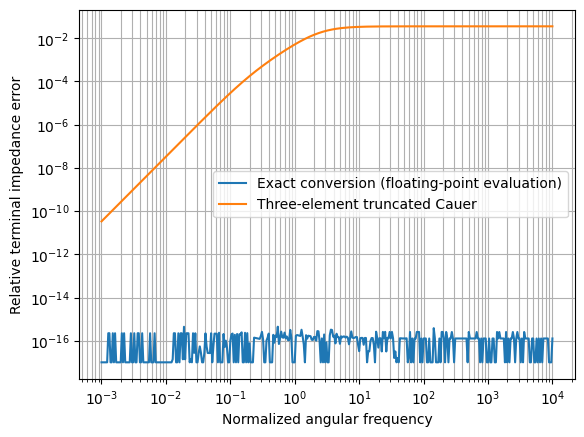

In [2]:
ladder = foster_to_cauer(z, s)
full = cauer_to_impedance(ladder, s)
truncated = cauer_to_impedance(ladder[:3], s)
assert sp.cancel(full-z) == 0
assert sp.cancel(truncated-z) != 0
omega = np.logspace(-3, 4, 400)
reference = sp.lambdify(s, z, 'numpy')(1j*omega)
converted = sp.lambdify(s, full, 'numpy')(1j*omega)
short = sp.lambdify(s, truncated, 'numpy')(1j*omega)
conversion_error = np.abs(converted-reference)/np.abs(reference)
truncation_error = np.abs(short-reference)/np.abs(reference)
print('Maximum floating-point conversion error:', conversion_error.max())
print('Maximum truncation relative error:', truncation_error.max())
assert conversion_error.max() < 1e-12
plt.loglog(omega, np.maximum(conversion_error, 1e-17), label='Exact conversion (floating-point evaluation)')
plt.loglog(omega, truncation_error, label='Three-element truncated Cauer')
plt.xlabel('Normalized angular frequency')
plt.ylabel('Relative terminal impedance error')
plt.legend(); plt.grid(True, which='both'); plt.show()

## What an error comparison must specify

| Step | Source of discrepancy | Appropriate check |
|---|---|---|
| Continuum problem → full finite element model | Mesh, order, geometry, boundary conditions, gauge treatment | Mesh/order convergence against a known solution or converged reference |
| Full finite element model → reduced model | Retained subspace, stage count, shifts, termination | Terminal and field errors for the same excitation and port |
| Sampled response → fitted Foster model | Sampling, pole selection, weighting, DC constraint | Independent frequencies, DC error, passivity and parameter budget |
| One realization → another of the same rational function | Zero in exact arithmetic; conditioning/roundoff in computation | Symbolic identity or numerical response residual |
| Continuous-time model → simulated trajectory | Time step, integration method, initialization | Time convergence and initial-condition consistency |

With $Z_{\rm FE}$ and $Z_{\rm ROM}$ defined for the same port, the triangle inequality gives

$$|Z_{\rm exact}-Z_{\rm ROM}|\le |Z_{\rm exact}-Z_{\rm FE}|+|Z_{\rm FE}-Z_{\rm ROM}|.$$

A small ROM error against a fixed mesh does not establish a small continuum error. Relative error also needs an explicit denominator and becomes ill-conditioned near zeros. Terminal impedance error is not a field-error bound: field reconstruction requires the retained spatial basis and its input/output maps. Magnetic energy and Joule loss provide useful additional checks but do not alone measure every spatial error.

Both CLN and snapshot methods in our comparison start from the **same actual excitation**. Boundary-response SVD is POD of its snapshots; Steklov eigenmodes come from a boundary operator and are not automatically POD. Surface enrichment can introduce coupled reduced matrices. A passive terminal Foster realization may still be extracted from an appropriate collocated linear model, but its branches should not be presented as the original physical CLN field stages.

For a symmetric collocated linear model with $K\succeq0$ and $M\succ0$, the pencil can be diagonalized after mass normalization. For example, $H(s)=b^T(K+sM)^{-1}b$ has nonnegative modal weights over poles $-\lambda_k$ (a zero eigenvalue requires a separate DC term). Whether the physical port quantity is $H$, $sH$, an inverse, or includes a feedthrough term depends on the formulation. A terminal fit by itself does not supply this field mapping.

## Published estimators versus the measured errors here

Hiruma, Clénet, Igarashi and Henneron [3] derive a guaranteed upper bound for CLN truncation error in their magnetoharmonic setting using complementary electric/magnetic formulations. That guarantee depends on their assumptions and construction. We do **not** implement that estimator in these experiments. The difference between two successive ladder responses is a convergence indicator, not an automatically guaranteed bound, and it does not cover finite element discretization error.

Tobita et al. [4] extend error estimation to time-domain analysis and a multiport application. This is relevant to extending the present work, but our nonlinear fixed-point experiment and its discrete-time Joule-loss check are not a reproduction of that theorem.

The stored three-dimensional experiment below reports measured error against the same fine-mesh full model. It compares four-state models over its recorded high band. Snapshot POD has access to a larger set of full responses offline; matching retained states does not match construction cost. The coarse/fine full-response discrepancy reported in [the experiment](08_3d_surface_pod_foster.ipynb) is approximately 3.46%, so the smaller reduction errors must not be read as continuum accuracy.

A Foster fit can prioritize a high-frequency band by relaxing DC constraints. That can improve that chosen objective, but is not a general proof that Foster outperforms physical CLN, especially for field reconstruction or another excitation. See [the fitting experiment](07_surface_hybrid_foster.ipynb).

In [3]:
import json
from IPython.display import display, Markdown
record = json.loads(Path('data/same_excitation_3d_fine.json').read_text(encoding='utf-8'))
rows = ['| Four-state model | Terminal max error [%] | Holdout terminal max [%] | Field max [%] |',
        '|---|---:|---:|---:|']
for name in ['ordinary CLN 4', 'multipoint CLN 4',
             'bulk2 + boundary-response POD 4', 'field POD 4']:
    result = record['runs'][name]
    assert result['rank'] == 4
    rows.append(f"| {name} | {100*result['high_band_max']:.5f} | "
                f"{100*result['holdout_high_band_max']:.5f} | "
                f"{100*result['field_high_band_max']:.5f} |")
display(Markdown('Measured high band: 1 kHz–1 MHz, same fine-mesh reference.\n\n' + '\n'.join(rows)))
print('These are measured reduction errors, not guaranteed continuum bounds.')

Measured high band: 1 kHz–1 MHz, same fine-mesh reference.

| Four-state model | Terminal max error [%] | Holdout terminal max [%] | Field max [%] |
|---|---:|---:|---:|
| ordinary CLN 4 | 1.06574 | 1.05803 | 30.10261 |
| multipoint CLN 4 | 0.07360 | 0.07360 | 6.50676 |
| bulk2 + boundary-response POD 4 | 0.05016 | 0.04919 | 6.76828 |
| field POD 4 | 0.03038 | 0.03038 | 5.34979 |

These are measured reduction errors, not guaranteed continuum bounds.


## References

1. A. Kameari, H. Ebrahimi, K. Sugahara, Y. Shindo and T. Matsuo, “Cauer Ladder Network Representation of Eddy-Current Fields for Model Order Reduction Using Finite-Element Method,” *IEEE Transactions on Magnetics*, 54(3), article 7201804, 2018. [DOI](https://doi.org/10.1109/TMAG.2017.2743224). [Author conference digest](https://www.compumag.org/Proceedings/2017_Daejeon/papers/%5BPA-M1-2%5D_52.pdf).
2. Y. Otomo and H. Igarashi, “Synthesis of a Cauer Equivalent Circuit for Electric Devices From Computed and Measured Data,” *IEEE Transactions on Power Electronics*, 36(4), 4513–4521, 2021. [DOI](https://doi.org/10.1109/TPEL.2020.3022167). [Accepted manuscript](https://eprints.lib.hokudai.ac.jp/dspace/bitstream/2115/79884/2/Final_ver_TPEL_Cauer-1.pdf).
3. S. Hiruma, S. Clénet, H. Igarashi and T. Henneron, “Error Estimator for Cauer Ladder Network Representation,” *IEEE Transactions on Magnetics*, 58(9), article 7500904, 2022. [DOI](https://doi.org/10.1109/TMAG.2022.3165943). [Accepted manuscript](https://eprints.lib.hokudai.ac.jp/repo/huscap/all/99311/IEEE%20T%20Magn%2058-9_7500904.pdf).
4. M. Tobita, S. Clénet, S. Hiruma, W. Chen and T. Matsuo, “Error Estimation of the Cauer Ladder Network Method for the Time-Domain Analysis and Its Application to a Multiport System,” *IEEE Transactions on Magnetics*, 60(12), 1–4, 2024. [DOI](https://doi.org/10.1109/TMAG.2024.3466808). [Institutional record](https://sam.ensam.eu/handle/10985/26703).

The exact conversion code and illustrative circuit values in this notebook are self-contained examples. They do not reuse numerical benchmarks from these papers.